---
---
# MBA - 2026
## Dirección Financiera

### Profesor Fernando Díaz H.
---

## Instrumentos Norteamericanos
* Indices Accionarios
* Bonos del Tesoro

### Cargando librerías

In [1]:
%%capture
%pip install yfinance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

## El Paquete `yfinance`

`yfinance` es un paquete de Python para descargar datos financieros (precios, dividendos, splits) directamente desde Yahoo Finance. Es el equivalente en Python de lo que **tidyquant** ofrece en el ecosistema **tidyverse** de R.

## Índices Disponibles

A diferencia de `tidyquant`, que incluye una función (`tq_index()`) para descargar la composición y ponderación completa de un índice, `yfinance` no ofrece esa función directamente. Por eso, en esta versión trabajaremos con los tickers de los índices agregados que necesitamos para el análisis de riesgo y retorno:

In [3]:
tickers_info = {
    "^GSPC": "S&P 500",
    "^DJI": "Dow Jones",
    "^SP600": "S&P 600",
    "^TNX": "10Y Treasury Yield",
}
tickers_info

{'^GSPC': 'S&P 500',
 '^DJI': 'Dow Jones',
 '^SP600': 'S&P 600',
 '^TNX': '10Y Treasury Yield'}

# Evolución del SP500 en el Tiempo

Consideremos, por ejemplo, los últimos 30 años.

In [4]:
from datetime import date
from dateutil.relativedelta import relativedelta

end_date = date.today()
start_date = end_date - relativedelta(years=30)

sp500_data = yf.download("^GSPC", start=start_date, end=end_date, progress=False)
sp500_data.columns = sp500_data.columns.get_level_values(0)
sp500_data = sp500_data.reset_index()
sp500_data.head()

Price,Date,Close,High,Low,Open,Volume
0,1996-07-16,628.369995,631.989990,605.880005,629.799988,682980000
1,1996-07-17,634.070007,636.609985,628.369995,628.369995,513830000
2,1996-07-18,643.559998,644.440002,633.289978,634.070007,474460000
3,1996-07-19,638.729980,643.510010,635.500000,643.510010,408070000
4,1996-07-22,633.770020,638.729980,630.380005,638.729980,327300000


Grafiquemos el precio de cierre, ajustado por dividendos y splits:

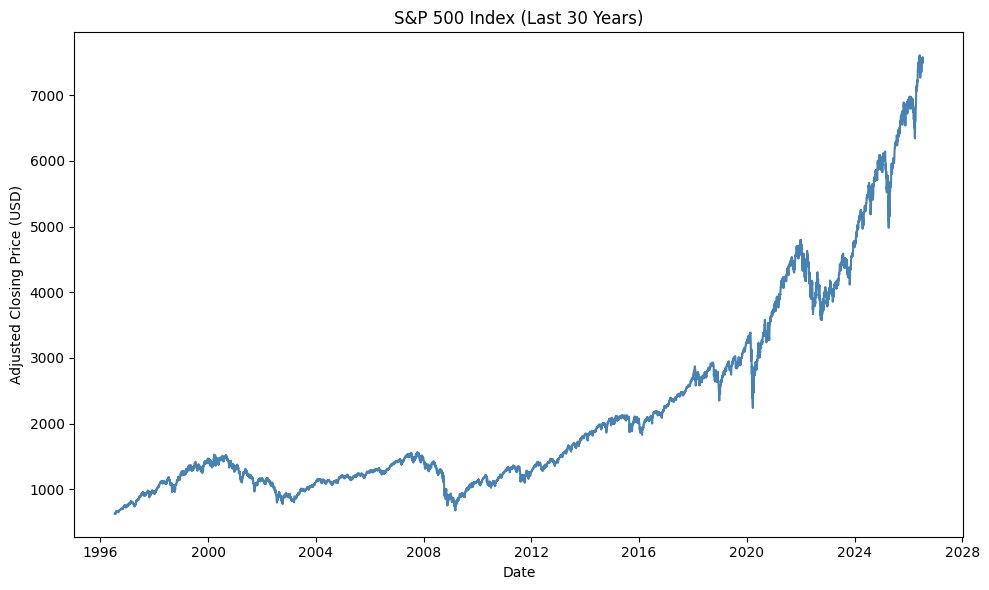

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sp500_data["Date"], sp500_data["Close"], color="steelblue", linewidth=1.5)
ax.set_title("S&P 500 Index (Last 30 Years)")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Closing Price (USD)")
plt.tight_layout()
plt.show()

# Diferentes Activos y Clases de Activos

Ahora, para el mismo periodo de tiempo, descargaremos el DOW, el SP600 y las series del Tesoro a 10 años con vencimiento constante.

Tanto el S&P 500, el S&P 600 como el Dow Jones Industrial Average (DJIA o "el Dow") pertenecen a la clase de **Renta Variable**, ya que están compuestos por acciones. Los bonos, por su parte, corresponden a la clase de **Renta Fija**.

### 📊 Diferencias entre el S&P 500, S&P 600 y el Dow

| Índice        | ¿Qué representa?                                                                 | Tipo de empresas             | Método de cálculo                      |
|---------------|----------------------------------------------------------------------------------|-------------------------------|----------------------------------------|
| **S&P 500**   | Las 500 mayores empresas de EE.UU. por capitalización bursátil.                  | **Large Cap** (grandes)       | Ponderado por capitalización de mercado |
| **S&P 600**   | 600 empresas pequeñas seleccionadas por su estabilidad y liquidez.               | **Small Cap** (pequeñas)      | Ponderado por capitalización de mercado |
| **Dow Jones** | 30 grandes empresas industriales líderes de EE.UU., muy conocidas.               | **Large Cap** (pero solo 30)  | **Ponderado por precio**, no por capitalización |

## Tendencias Temporales de los Diferentes Activos

* Representaremos todas las series en el mismo gráfico.
* También normalizaremos el precio de cada instrumento a 100 en la primera fecha para que todos los gráficos empiecen en el mismo punto.
* Consideremos el período que se inicia el año 2005.

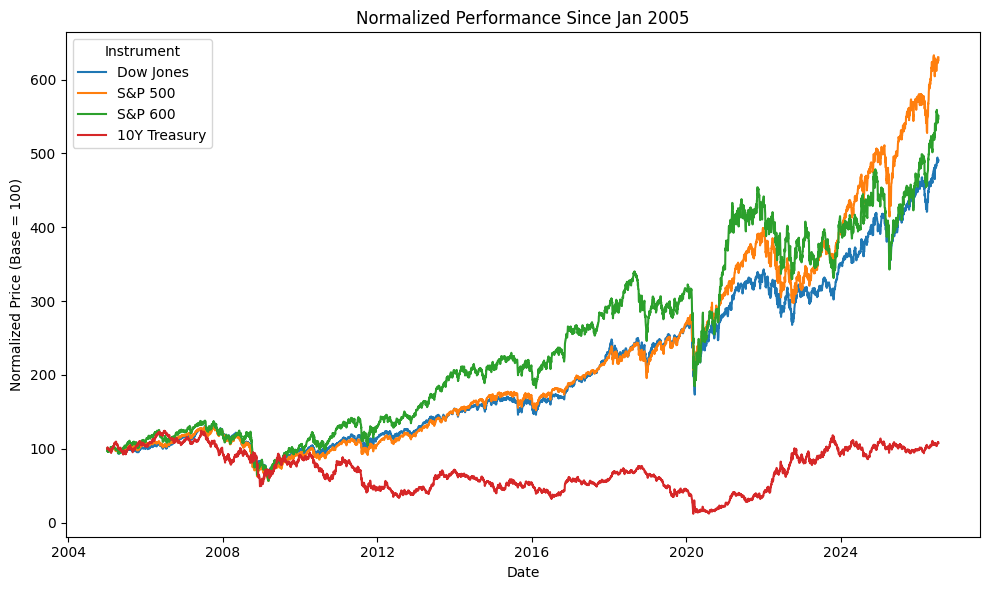

Ticker,Dow Jones,S&P 500,S&P 600,10Y Treasury
Date,,,,
2026-07-09,52487.410156,7543.640137,1769.479980,4.539
2026-07-10,52637.011719,7575.390137,1769.609985,4.569
2026-07-13,52498.640625,7515.339844,1762.760010,4.609
2026-07-14,52508.269531,7543.589844,1767.989990,4.585
2026-07-15,52658.640625,7572.399902,1777.020020,4.545


In [6]:
tickers = ["^GSPC", "^DJI", "^SP600", "^TNX"]
labels = {
    "^GSPC": "S&P 500",
    "^DJI": "Dow Jones",
    "^SP600": "S&P 600",
    "^TNX": "10Y Treasury",
}

start_date = pd.Timestamp("2005-01-01")
end_date = pd.Timestamp(date.today())

market_data = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]
market_data = market_data.rename(columns=labels)

normalized_data = market_data.div(market_data.bfill().iloc[0]) * 100

fig, ax = plt.subplots(figsize=(10, 6))
for col in normalized_data.columns:
    ax.plot(normalized_data.index, normalized_data[col], linewidth=1.5, label=col)
ax.set_title("Normalized Performance Since Jan 2005")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price (Base = 100)")
ax.legend(title="Instrument")
plt.tight_layout()
plt.show()

market_data.tail()

OK. Nótese que la serie de los bonos del tesoro está expresada en puntos porcentuales. Podemos calcular un precio aproximado:

$$
\text{Price}_t = \frac{100}{(1 + r_t)^{10}}
$$

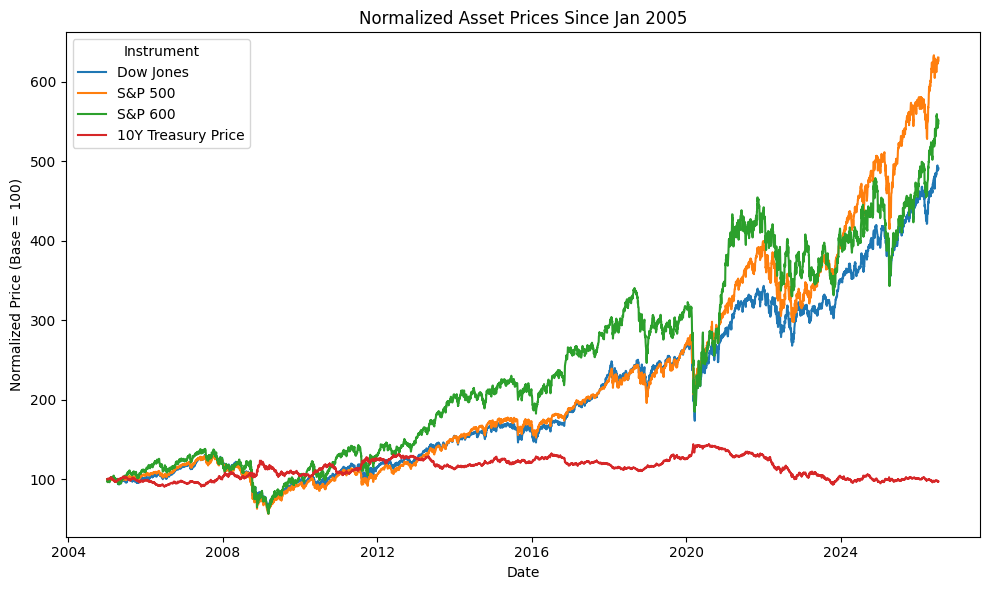

In [7]:
bond_price = 100 / (1 + market_data["10Y Treasury"] / 100) ** 10

full_data = market_data.drop(columns=["10Y Treasury"]).copy()
full_data["10Y Treasury Price"] = bond_price

normalized_data = full_data.div(full_data.bfill().iloc[0]) * 100

fig, ax = plt.subplots(figsize=(10, 6))
for col in normalized_data.columns:
    ax.plot(normalized_data.index, normalized_data[col], linewidth=1.5, label=col)
ax.set_title("Normalized Asset Prices Since Jan 2005")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price (Base = 100)")
ax.legend(title="Instrument")
plt.tight_layout()
plt.show()

# Tendencias

## Tendencias Lineales

Agreguemos una tendencia a cada uno de estos activos:

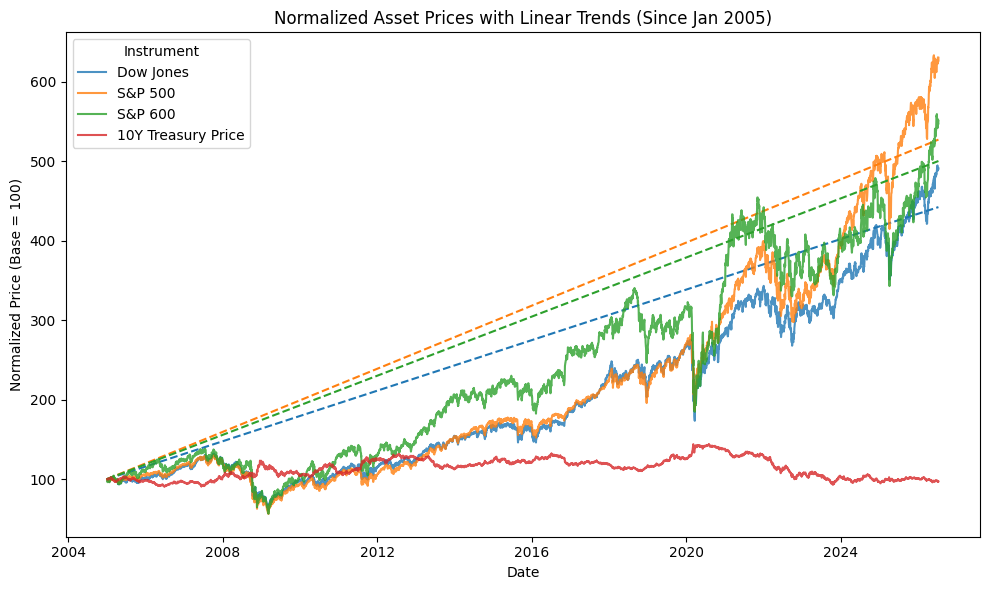

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

days_since_start = (normalized_data.index - normalized_data.index.min()).days.values

for col in normalized_data.columns:
    series = normalized_data[col]
    coeffs = np.polyfit(days_since_start, series.values, 1)
    trend = np.polyval(coeffs, days_since_start)
    shift = series.values[0] - trend[0]
    trend = trend + shift

    line, = ax.plot(normalized_data.index, series, linewidth=1.5, alpha=0.8, label=col)
    ax.plot(normalized_data.index, trend, linestyle="--", linewidth=1.5, color=line.get_color())

ax.set_title("Normalized Asset Prices with Linear Trends (Since Jan 2005)")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price (Base = 100)")
ax.legend(title="Instrument")
plt.tight_layout()
plt.show()

## Retornos Históricos de cada Serie

In [9]:
tnx_yield = market_data["10Y Treasury"] / 100
avg_yield_percent = round(tnx_yield.mean() * 100, 2)

log_returns = np.log(full_data.drop(columns=["10Y Treasury Price"]) / full_data.drop(columns=["10Y Treasury Price"]).shift(1))

average_returns = pd.DataFrame({
    "annual_percent": round(log_returns.mean() * 252 * 100, 2)
})
average_returns.index.name = "label"
average_returns = average_returns.reset_index()

final_summary = pd.concat([
    average_returns,
    pd.DataFrame([{"label": "10Y Treasury Yield", "annual_percent": avg_yield_percent}])
], ignore_index=True)

final_summary

,label,annual_percent
0,Dow Jones,7.40
1,S&P 500,8.57
2,S&P 600,7.94
3,10Y Treasury Yield,3.00


## Volatilidad de Cada Serie

Deberíamos observar que a mayor retorno, existe mayor volatilidad.

In [10]:
returns_summary = pd.DataFrame({
    "return_percent": round(log_returns.mean() * 252 * 100, 2),
    "vol_percent": round(log_returns.std() * np.sqrt(252) * 100, 2),
})
returns_summary.index.name = "label"
returns_summary = returns_summary.reset_index()

tnx_stats = pd.DataFrame([{
    "label": "10Y Treasury Yield",
    "return_percent": round(tnx_yield.mean() * 100, 2),
    "vol_percent": round(tnx_yield.std() * 100, 2),
}])

final_summary = pd.concat([returns_summary, tnx_stats], ignore_index=True)
final_summary = final_summary.sort_values("vol_percent").reset_index(drop=True)
final_summary.insert(0, "Ranking Riesgo", range(1, len(final_summary) + 1))
final_summary = final_summary.rename(columns={
    "label": "Activo",
    "return_percent": "Retorno Anual (%)",
    "vol_percent": "Volatilidad Anual (%)",
})

final_summary.style.hide(axis="index")

Ranking Riesgo,Activo,Retorno Anual (%),Volatilidad Anual (%)
1,10Y Treasury Yield,3.000000,1.140000
2,Dow Jones,7.400000,18.000000
3,S&P 500,8.570000,19.070000
4,S&P 600,7.940000,23.760000
